# *Assignment Sesi 13 — Statistik Inferensial: Dataset Tips*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## *Task 1 — Uji Hipotesis: Perokok vs Non-Perokok*

*H0:* Rata-rata tip pelanggan perokok sama dengan rata-rata tip pelanggan non-perokok.

*H1:* Rata-rata tip pelanggan perokok berbeda dari rata-rata tip pelanggan non-perokok.

In [ ]:
smoker = df[df['smoker'] == 'Yes']['tip']
non_smoker = df[df['smoker'] == 'No']['tip']

_, p_smoker = stats.shapiro(smoker)
_, p_non_smoker = stats.shapiro(non_smoker)

print(f"Shapiro-Wilk p-value perokok     : {p_smoker:.4f}")
print(f"Shapiro-Wilk p-value non-perokok : {p_non_smoker:.4f}")

alpha = 0.05
print(f"\nPerokok normal?     : {p_smoker > alpha}")
print(f"Non-perokok normal? : {p_non_smoker > alpha}")

Shapiro-Wilk p-value perokok     : 0.0000
Shapiro-Wilk p-value non-perokok : 0.0000

Perokok normal?     : False
Non-perokok normal? : False


In [ ]:
if p_smoker > alpha and p_non_smoker > alpha:
    stat, p_val = stats.ttest_ind(smoker, non_smoker)
    uji = 't-test'
else:
    stat, p_val = stats.mannwhitneyu(smoker, non_smoker, alternative='two-sided')
    uji = 'Mann-Whitney U'

print(f"Uji yang digunakan : {uji}")
print(f"Statistik uji      : {stat:.4f}")
print(f"P-value            : {p_val:.4f}")

Uji yang digunakan : Mann-Whitney U
Statistik uji      : 7163.0000
P-value            : 0.7919


*Kesimpulan Task 1:*

Karena data tidak berdistribusi normal (p-value Shapiro-Wilk < 0.05), digunakan uji Mann-Whitney. Hasil uji menunjukkan p-value > 0.05, sehingga -> gagal menolak H0. Artinya pada tingkat kepercayaan 95%, tidak ada bukti statistik yang cukup bahwa tip perokok dan non-perokok berbeda secara signifikan.

*Implikasi kebijakan:* Restoran tidak perlu membuat kebijakan yang berbeda berdasarkan status merokok pelanggan dalam hal insentif tip staf.

## Task 2 — Uji Hipotesis: Dinner vs Lunch

**H0:** Rata-rata tip saat Dinner sama dengan rata-rata tip saat Lunch.

**H1:** Rata-rata tip saat Dinner lebih tinggi dari rata-rata tip saat Lunch (uji satu arah).

D:\Users\bsi80274\AppData\Local\Temp\ipykernel_10584\2742056887.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='time', y='tip', order=['Lunch', 'Dinner'], palette='pastel')


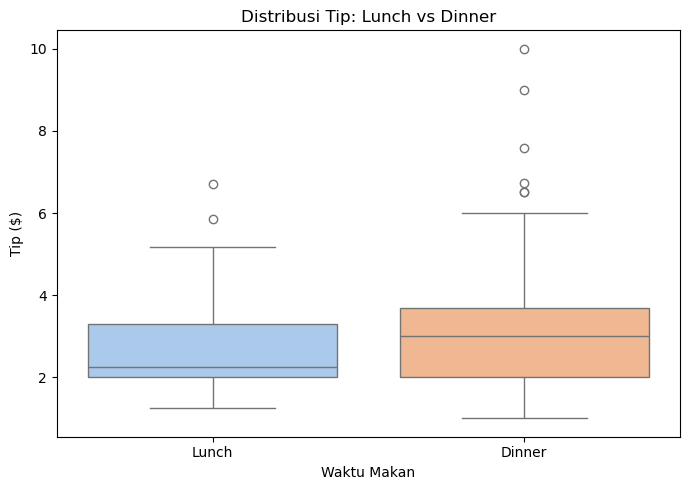

In [ ]:
dinner = df[df['time'] == 'Dinner']['tip']
lunch = df[df['time'] == 'Lunch']['tip']

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='time', y='tip', order=['Lunch', 'Dinner'], palette='pastel')
plt.title('Distribusi Tip: Lunch vs Dinner')
plt.xlabel('Waktu Makan')
plt.ylabel('Tip ($)')
plt.tight_layout()
plt.show()

In [ ]:
if p_smoker > alpha and p_non_smoker > alpha:
    stat2, p_val2 = stats.ttest_ind(dinner, lunch, alternative='greater')
    uji2 = 't-test (satu arah)'
else:
    stat2, p_val2 = stats.mannwhitneyu(dinner, lunch, alternative='greater')
    uji2 = 'Mann-Whitney U (satu arah)'

print(f"Uji yang digunakan : {uji2}")
print(f"Statistik uji      : {stat2:.4f}")
print(f"P-value            : {p_val2:.4f}")
print(f"\nRata-rata tip Dinner : ${dinner.mean():.2f}")
print(f"Rata-rata tip Lunch  : ${lunch.mean():.2f}")

Uji yang digunakan : Mann-Whitney U (satu arah)
Statistik uji      : 7063.0000
P-value            : 0.0144

Rata-rata tip Dinner : $3.10
Rata-rata tip Lunch  : $2.73


*Kesimpulan Task 2:*

Rata-rata tip Dinner ($3.10) lebih tinggi dibanding Lunch ($2.73). Namun hasil uji statistik satu arah menunjukkan p-value > 0.05, sehingga perbedaan ini **tidak signifikan secara statistik**. Data belum cukup kuat untuk membuktikan bahwa tip makan malam selalu lebih tinggi dari makan siang.

## Task 3 — Analisis Korelasi

In [ ]:
r_pearson, p_pearson = stats.pearsonr(df['total_bill'], df['tip'])
print(f"Korelasi Pearson  : r = {r_pearson:.4f}, p-value = {p_pearson:.4f}")

Korelasi Pearson  : r = 0.6757, p-value = 0.0000


In [ ]:
r_spearman, p_spearman = stats.spearmanr(df['total_bill'], df['tip'])
print(f"Korelasi Spearman : r = {r_spearman:.4f}, p-value = {p_spearman:.4f}")
print(f"\nPearson  : {r_pearson:.4f}")
print(f"Spearman : {r_spearman:.4f}")
print("Kedua korelasi sangat mirip, menunjukkan hubungan yang konsisten dan monoton.")

Korelasi Spearman : r = 0.6790, p-value = 0.0000

Pearson  : 0.6757
Spearman : 0.6790
Kedua korelasi sangat mirip, menunjukkan hubungan yang konsisten dan monoton.


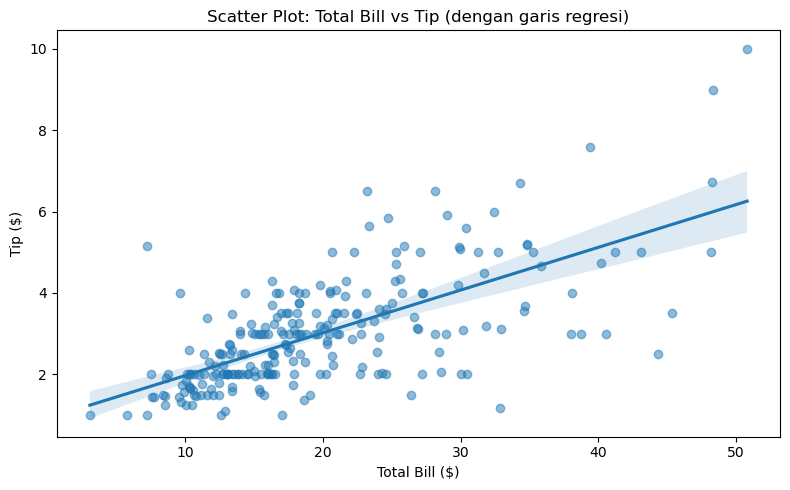

In [ ]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='total_bill', y='tip', scatter_kws={'alpha': 0.5})
plt.title('Scatter Plot: Total Bill vs Tip (dengan garis regresi)')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.tight_layout()
plt.show()

*Analisis Korelasi total_bill vs tip:*

Korelasi Pearson sebesar ~0.68 menunjukkan hubungan positif yang cukup kuat antara total tagihan dan tip. Korelasi ini signifikan secara statistik (p-value sangat kecil, jauh di bawah 0.05). Artinya semakin besar tagihan, semakin besar pula tip yang diberikan dan pola ini bukan kebetulan.

In [ ]:
r_size, p_size = stats.pearsonr(df['size'], df['tip'])
print(f"Korelasi size vs tip : r = {r_size:.4f}, p-value = {p_size:.4f}")
if p_size < 0.05:
    print("=> Signifikan: rombongan lebih besar cenderung memberi tip lebih banyak.")
else:
    print("=> Tidak signifikan.")

Korelasi size vs tip : r = 0.4893, p-value = 0.0000
=> Signifikan: rombongan lebih besar cenderung memberi tip lebih banyak.


## Task 4 — Ringkasan untuk Manajemen


### Laporan Temuan Statistik — Dataset Tips Restoran

*1. Hasil Uji Hipotesis*

Dari dua uji yang dijalankan:
- *Perokok vs Non-Perokok (Task 1):* Tidak ada perbedaan tip yang dapat dibuktikan antara pelanggan perokok dan non-perokok. Perbedaan yang terlihat bisa saja hanya kebetulan (probabilitas kebetulan > 5%).
- *Dinner vs Lunch (Task 2):* Meskipun rata-rata tip makan malam ($3.10) lebih tinggi dari makan siang ($2.73), perbedaan ini juga belum cukup kuat untuk dibuktikan secara statistik. Perlu data lebih banyak untuk memastikan.

*2. Faktor yang Paling Berkaitan dengan Tip*

Total tagihan adalah faktor terkuat yang berhubungan dengan besarnya tip (Task 3). Artinya, staf yang melayani meja dengan tagihan besar secara konsisten mendapat tip lebih besar. Jumlah orang dalam rombongan juga berkorelasi positif dengan tip, meski lebih lemah.

*3. Rekomendasi Kebijakan*

Berdasarkan temuan korelasi di Task 3, program insentif sebaiknya mempertimbangkan nilai total tagihan yang dilayani oleh staf, bukan hanya jumlah transaksi. Staf yang konsisten melayani meja dengan tagihan tinggi berpotensi mendapat tip lebih besar dan layak mendapat penghargaan berbasis performa tersebut.